In [ ]:
from joblib import Parallel, delayed
import os
os.environ['R_HOME'] = '/public/home/liuzj/softwares/anaconda3/envs/hormone_new/lib/R'
import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
import rpy2.ipython.html
rpy2.ipython.html.init_printing()
from jpy_tools.rTools import py2r, r2py, r_inline_plot, rHelp, trl, rSet, rGet, ad2so, so2ad, so2md, rcontext, Trl, r2py_re, py2r_re, RR, FR
from jpy_tools import loadPkl, toPkl
rBase = importr('base')
rUtils = importr('utils')
dplyr = importr('dplyr')
reticulate = importr('reticulate')
R = ro.r
T = Trl()
R("options(browser='firefox', shiny.port=6533, max.print=200)")
%load_ext rpy2.ipython


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

<Figure size 100x100 with 0 Axes>

In [ ]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
import scipy.sparse as ss
from tqdm import tqdm
from loguru import logger
from functools import partial
from jpy_tools import singleCellTools

In [ ]:
%config InlineBackend.figure_format = 'retina'
import seaborn as sns
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import marsilea as ma
import marsilea.plotter as mp
# plt.rcParams['figure.dpi'] = 150
font_dirs = ["/public/home/mowp/test/fonts/"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "Arial"
sns.despine(top=True, right=True)
from itertools import product
from functools import reduce
import patchworklib as pw
from jpy_tools.otherTools import pwRecoverSeaborn, pwStack, F, pwShow
pw.show = pwShow
fc_recoverSns = pwRecoverSeaborn()
import seaborn.objects as so
from cycler import cycler
dt_snsStyle = {**sns.axes_style('ticks'), "legend.frameon": False, "axes.spines.top":False, "axes.spines.right":False, "axes.prop_cycle":cycler(color=['grey'])}
so.Plot.config.theme.update(dt_snsStyle)

<Figure size 640x480 with 0 Axes>

In [ ]:
dir_result = '/data/Zhaijx/liuzj/projects/singleCell/hormone/res/'

# load data

In [ ]:
ad = sc.read_h5ad(
    "/data/Zhaijx/liuzj/projects/singleCell/hormone/res/ad_all_processed.h5ad"
) # The Annotated and Processed Single-cell Dataset According to Our Analysis Pipeline, Please See the `QC_Clustering.ipynb` Notebook for Details

In [ ]:
ead = singleCellTools.EnhancedAnndata(ad)

# Prepare Input Data for GRN Construction

In [ ]:
def prepareOutputForMiniex(ead, dir_miniex, prefix, clusterKey, annoKey, layer="raw", geneDiffLayer='normalize_log'):
    import pyarrow as pa
    import pyarrow.csv as csv
    import os

    df_allCount = ead.ad.T.to_df(layer)
    df_allCount.rename_axis('geneid', inplace=True)
    a = df_allCount.reset_index()
    a.to_feather(f"{dir_miniex}/{prefix}_matrix.feather")
    logger.info(f"Saved {dir_miniex}/{prefix}_matrix.feather")

    new_pa_dataframe = pa.Table.from_pandas(a)
    csv.write_csv(
        new_pa_dataframe,
        f"{dir_miniex}/{prefix}_matrix.tsv.1",
        write_options=csv.WriteOptions(delimiter="\t", include_header=False, quoting_style="none"),
    )
    df_allCount.head(0).to_csv(f"{dir_miniex}/{prefix}_matrix.tsv.2", sep="\t")
    os.system(
        f"cat {dir_miniex}/{prefix}_matrix.tsv.2 {dir_miniex}/{prefix}_matrix.tsv.1 > {dir_miniex}/{prefix}_matrix.tsv"
    )
    os.system(
        f"rm {dir_miniex}/{prefix}_matrix.tsv.1 {dir_miniex}/{prefix}_matrix.tsv.2"
    )
    logger.info(f"Saved {dir_miniex}/{prefix}_matrix.tsv")

    sc.tl.rank_genes_groups(
        ead.ad,
        groupby=f"{clusterKey}",
        method="wilcoxon",
        layer=geneDiffLayer,
        use_raw=False,
        pts=True,
        key_added=f"{clusterKey}_rank_genes",
    )
    df_markers = sc.get.rank_genes_groups_df(ead.ad, None, key=f"{clusterKey}_rank_genes", log2fc_min=0.25)
    df_markers = df_markers.query("pvals < 0.01 & pct_nz_group > 0.05")
    df_markers = df_markers.rename(
        columns={
            "names": "geneID",
            "pvals": "p_val",
            "logfoldchanges": "avg_logFC",
            "pct_nz_group": "pct.1",
            "pct_nz_reference": "pct.2",
            "pvals_adj": "p_val_adj",
            "group": "cluster",
        }
    ).reindex(
        columns=["geneID", "p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj", "cluster"]
    ).assign(
        gene=lambda _: _.geneID
    )
    _min = min(df_markers['p_val'].loc[lambda _: _ > 0].min(), 1e-100)
    df_markers['p_val'] = df_markers['p_val'].map(lambda _: max(_, _min))
    df_markers.sort_values(["cluster", "p_val"]).to_csv(
        f"{dir_miniex}/{prefix}_allMarkers.tsv", sep="\t", index=False, quoting=None
    )
    logger.info(f"Saved {dir_miniex}/{prefix}_allMarkers.tsv")

    ead.obs[['ClusterMiniex']].to_csv(f"{dir_miniex}/{prefix}_cells2clusters.tsv", sep="\t", quoting=None, header=False)
    ead.obs[[clusterKey, annoKey]].drop_duplicates().set_index(clusterKey).sort_values(
        clusterKey
    ).to_csv(f"{dir_miniex}/{prefix}_identities.tsv", sep="\t", quoting=None, header=False)
    logger.info(f"Saved {dir_miniex}/{prefix}_identities.tsv")

In [ ]:
ead.obs['annoOnly'] = ead.obs['Cluster_ft_anno'].map(lambda _: _.split(': ')[-1])
ead.obs["ClusterMiniex"] = (
    ead.obs["Cluster_ft"].astype(str)
    + "-"
    + ead.obs["Hormone"].astype(str)
)

In [ ]:
ls_hormone = ['SA','ABA', 'Mock', 'JA']
ls_shoot = [
        # Shoot-related
        "6",       # Shoot Apical Meristem
        "3", "4",  # Shoot Epidermal Cell
        "24",      # Guard Cell
        "0", "1", "7", "11", "16"  # Mesophyll Cell
    ]

2025-05-20 17:46:53.079 | DEBUG    | jpy_tools.singleCellTools.plotting:_embedding:1597 - ls_color: ['6', '3', '4', '24', '0', '1', '7', '11', '16']
2025-05-20 17:47:02.225 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1730 - Title location: 0.8938888888888888


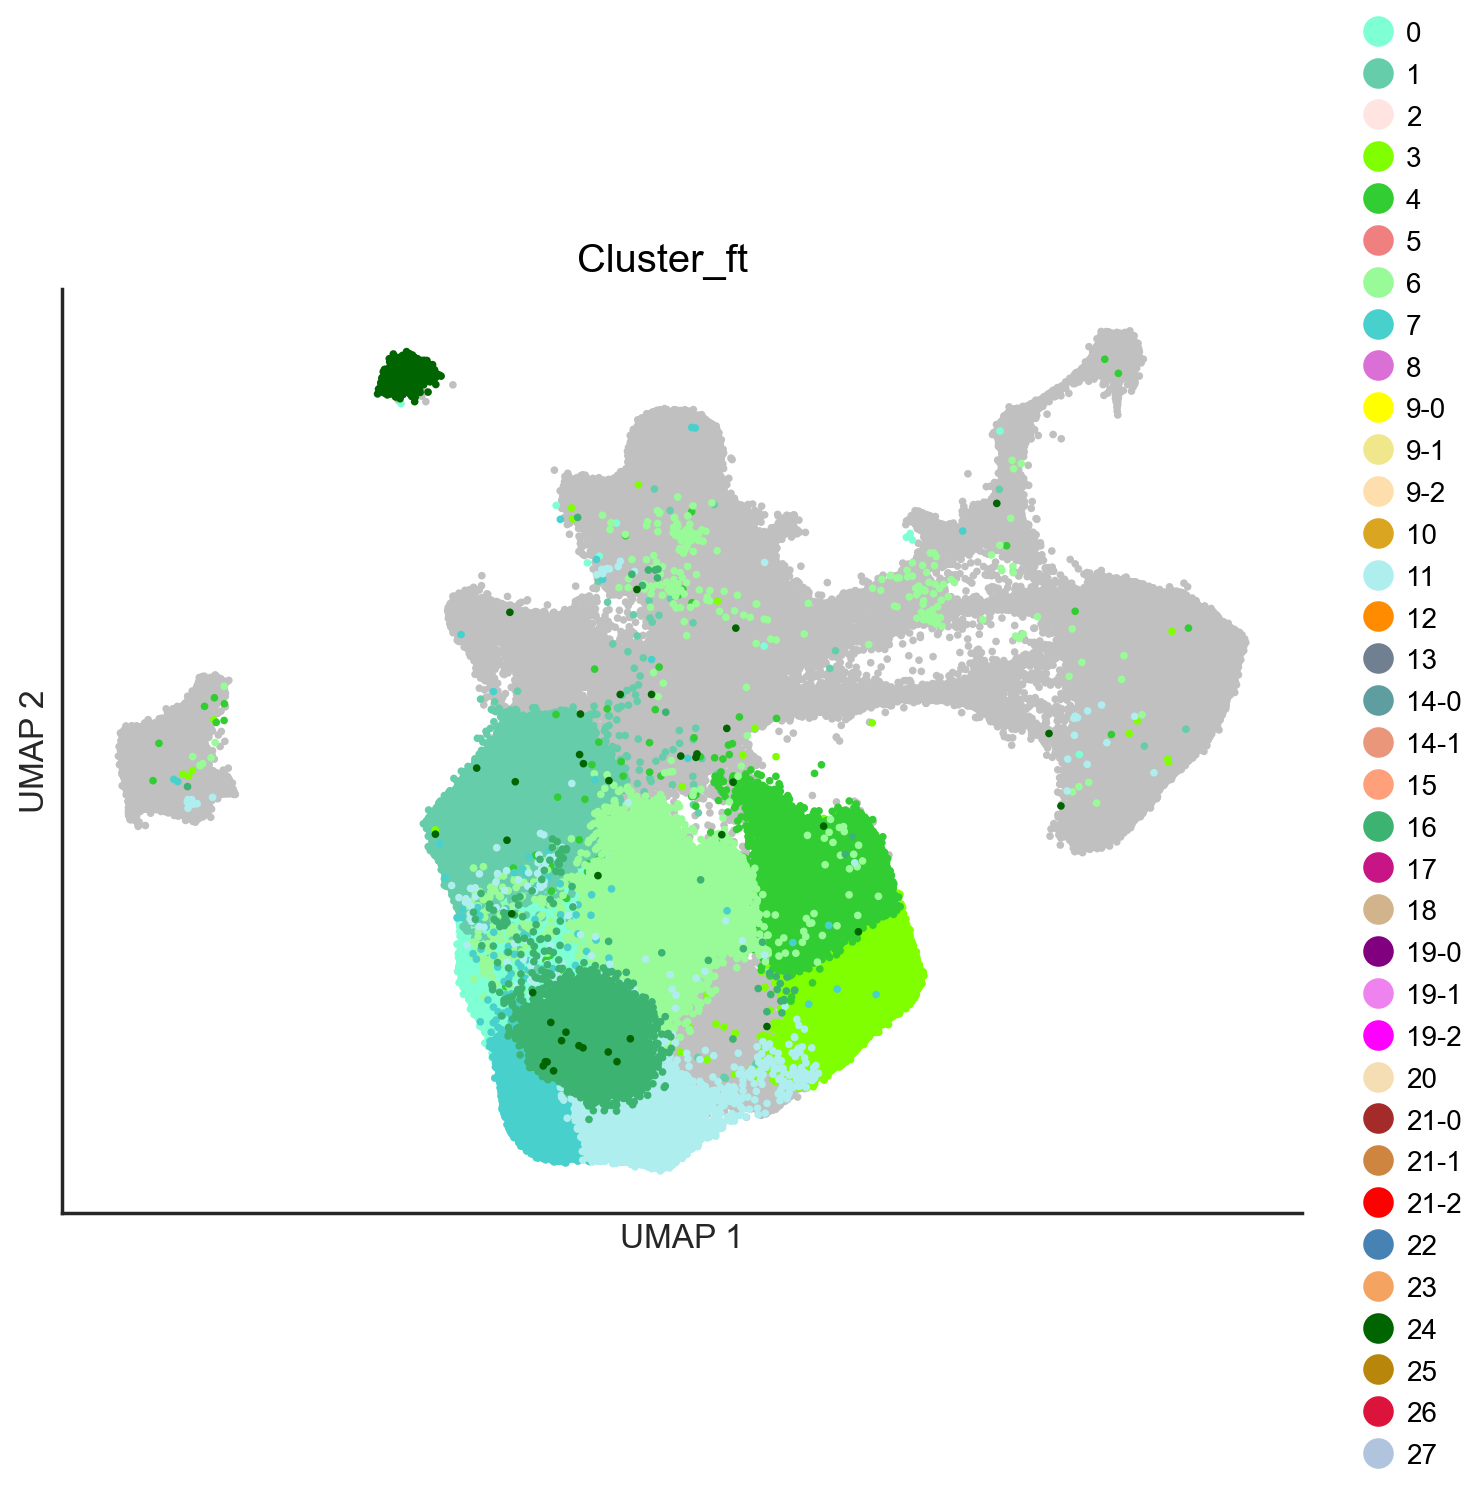

In [ ]:
ead.pl.embedding(
    color='Cluster_ft', ls_color=ls_shoot
)

In [ ]:
ead_shootAndResponseHormone = ead[ead.obs.query("Cluster_ft.isin(@ls_shoot) & Hormone.isin(@ls_hormone)").index].copy()

In [ ]:
prepareOutputForMiniex(
    ead_shootAndResponseHormone,
    "/datapool/data/Users/zhijian/github/MINI-EX/hormone/jaSaAbaShootOnly/input/",
    "jaSaAbaShootOnly",
    "ClusterMiniex",
    "annoOnly",
    layer="raw",
    geneDiffLayer="normalize_log",
)

2025-04-03 10:17:19.647 | INFO     | __main__:prepareOutputForMiniex:10 - Saved /datapool/data/Users/zhijian/github/MINI-EX/hormone/jaSaAbaShootOnly/input//jaSaAbaShootOnly_matrix.feather
2025-04-03 10:19:47.157 | INFO     | __main__:prepareOutputForMiniex:25 - Saved /datapool/data/Users/zhijian/github/MINI-EX/hormone/jaSaAbaShootOnly/input//jaSaAbaShootOnly_matrix.tsv
2025-04-03 10:28:12.984 | INFO     | __main__:prepareOutputForMiniex:58 - Saved /datapool/data/Users/zhijian/github/MINI-EX/hormone/jaSaAbaShootOnly/input//jaSaAbaShootOnly_allMarkers.tsv
2025-04-03 10:28:13.494 | INFO     | __main__:prepareOutputForMiniex:64 - Saved /datapool/data/Users/zhijian/github/MINI-EX/hormone/jaSaAbaShootOnly/input//jaSaAbaShootOnly_identities.tsv


# Parse Miniex output

## get DE TF

In [ ]:
ead_sketch = ead[ead.obs["sketch"]].copy()
ead_sketchMiniex = ead[
    ead.obs.query("Cluster_ft.isin(@ls_shoot) & Hormone.isin(@ls_hormone)").index
].copy()

In [ ]:
ead_sketchMiniex.cl.getClusterSpecGeneByCellex('ClusterMiniex')

cutoff         0.60  0.70  0.80  0.90  0.95  0.99
ClusterMiniex                                    
3-SA           1300   917   567   244    93     5
1-SA           1288   943   606   265   130    12
4-SA            924   619   355   137    47     2
0-Mock          911   649   402   176    71     5
1-ABA           906   641   407   140    43     5
3-ABA           905   649   399   182    74     8
1-Mock          903   642   384   161    62     7
0-JA            886   621   405   162    63     4
1-JA            859   606   337   139    47     7
3-JA            831   597   381   182    68     4
0-ABA           815   591   368   155    63     4
4-Mock          804   572   378   162    65     3
0-SA            799   543   337   126    34     1
4-JA            788   550   358   147    60     3
4-ABA           764   549   342   126    31     2
11-SA           756   496   329   131    49     0
6-ABA           738   543   325   134    58     6
3-Mock          696   496   304   135    48     4


In [ ]:
df_deGeneVsOthersSketch = ead_sketchMiniex.uns['ClusterMiniex_cellexES'].query("enrichScore > 0.8")

In [ ]:
df_miniex = pd.read_table(
    "/datapool/data/Users/zhijian/github/MINI-EX/hormone/jaSaAbaShootOnly/output/regulons/jaSaAbaShootOnly_regulons.tsv",
    names=["regulon", "cluster", "genes"],
) # The Output From MINI-EX

In [ ]:
df_miniex = df_miniex.assign(
    regulon_name=lambda _: _.regulon + "-" + _.cluster, TF=lambda _: _.regulon
).set_index("regulon_name")

In [ ]:
ls_allTf = df_miniex['TF'].drop_duplicates()

In [ ]:
df_tfSpecInfo = pd.DataFrame(index=ead_sketchMiniex.obs['ClusterMiniex'].cat.categories, columns=ls_allTf)
for clMiniex in df_tfSpecInfo.index:
    df_temp = ead_sketchMiniex.uns['ClusterMiniex_cellexES'].query("ClusterMiniex == @clMiniex & expressed_ratio > 0.1")
    df_temp['new_score'] = np.where(df_temp['expressed_ratio'] > 0.1, df_temp['enrichScore'], 0)
    sr_temp = df_temp.set_index('gene')['new_score']
    df_tfSpecInfo.loc[clMiniex, df_temp['gene']] = sr_temp
df_tfSpecInfo.fillna(0, inplace=True)

In [ ]:
ls_kept = (
    ead_sketchMiniex.uns["ClusterMiniex_cellexES"]
    .query("enrichScore > 0.8 & expressed_ratio > 0.1 & gene in @ls_allTf")
    .sort_values("ClusterMiniex")["gene"]
    .drop_duplicates()
)

In [ ]:
df_tfSpecInfoForPlot = df_tfSpecInfo[ls_kept]

In [ ]:
df_borda = pd.read_table(
    "/datapool/data/Users/zhijian/github/MINI-EX/hormone/jaSaAbaShootOnly/output/regulons/jaSaAbaShootOnly_rankedRegulons.tsv"
) # The Output From MINI-EX
ls_tfRelatedWithStomatol = df_borda.query("hasTFrelevantGOterm == 'relevant_known_TF'")['TF'].unique().tolist() >> F(set)

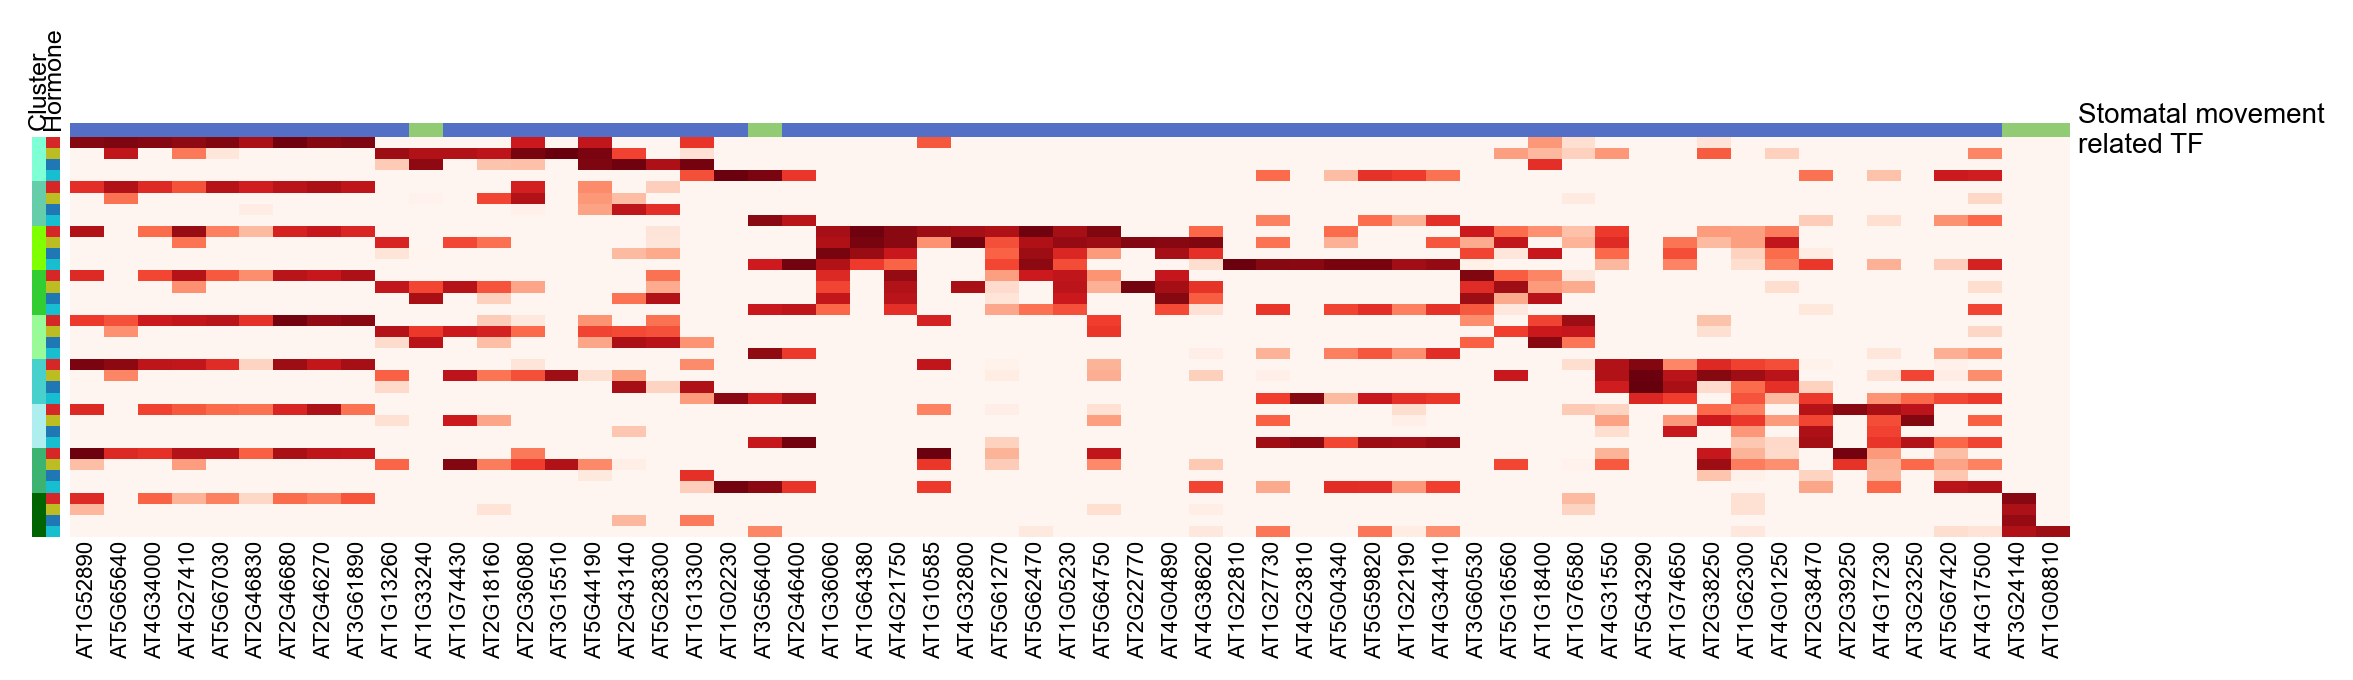

In [ ]:
h = ma.Heatmap(
    df_tfSpecInfoForPlot.values,
    width=10,
    height=2,
    cmap="Reds",
    vmax=1,
    label="Cluster specificity score",
)
h.add_left(
    mp.Colors(
        df_tfSpecInfoForPlot.index.str.split("-").str[1],
        palette={
            x: ead.pl.getAdColors("Hormone")[x] for x in ["Mock", "ABA", "JA", "SA"]
        },
        label="Hormone", label_loc='top',
        label_props={"size": 9},
    ),
    size=0.07,
    pad=0.05,
)
h.add_left(
    mp.Colors(
        df_tfSpecInfoForPlot.index.str.split("-").str[0],
        palette={
            x: ead.pl.getAdColors("Cluster_ft")[x] for x in df_tfSpecInfoForPlot.index.str.split("-").str[0].unique()
        },
        label="Cluster",label_loc='top',
        label_props={"size": 9},
    ),
    size=0.07,
)
h.add_bottom(mp.Labels(df_tfSpecInfoForPlot.columns, size=8))
h.add_top(
    mp.Colors(
        df_tfSpecInfoForPlot.columns.isin(ls_tfRelatedWithStomatol),
        label="Stomatal movement\nrelated TF",
        label_props={"size": 10},
    ),
    size=0.07,
)
# h.add_legends()
h.render()

# plot network

In [ ]:
df_edge = pd.read_table("/datapool/data/Users/zhijian/github/MINI-EX/hormone/jaSaAbaShootOnly/output/regulons/jaSaAbaShootOnly_edgeTable.tsv") # The Output From MINI-EX
df_edge = df_edge.query("cluster=='Cluster_24-SA' & TF == 'AT1G08810'") # Filter for the Regulon of TF AT1G08810 in Cluster 24 under SA Treatment

In [ ]:
import networkx as nx

In [ ]:
ls_myb60TgStoRelated = """AT3G49260
AT4G14480
AT3G56400
AT2G46070
AT5G26000
AT5G54270
AT2G16630
AT3G24140""".split()

In [ ]:
df_edge

,TF,TG,cluster,borda_rank,borda_clusterRank,weight
11980,AT1G08810,AT3G17070,Cluster_24-SA,18,5,58.695842
11981,AT1G08810,AT1G11850,Cluster_24-SA,18,5,37.487240
11982,AT1G08810,AT5G15230,Cluster_24-SA,18,5,29.314792
11983,AT1G08810,AT1G79910,Cluster_24-SA,18,5,28.133942
11984,AT1G08810,AT4G14440,Cluster_24-SA,18,5,26.314982
...,...,...,...,...,...,...
12120,AT1G08810,AT5G02380,Cluster_24-SA,18,5,0.024664
12121,AT1G08810,AT4G02380,Cluster_24-SA,18,5,0.019354
12122,AT1G08810,AT1G70600,Cluster_24-SA,18,5,0.009746
12123,AT1G08810,AT5G63790,Cluster_24-SA,18,5,0.004782


In [ ]:
dt_myb50TgStoRelated = {
    x: y
    for x, y in zip(
        ls_myb60TgStoRelated,
        ["IQD21", "BLUS1", "WRKY70", "MPK12", "TGG1", "LHCB3", "FOCL1", "FAMA"],
    )
}
dt_myb50TgStoRelated['AT1G08810'] = 'MYB60'

2025-05-22 17:00:11.633 | INFO     | jpy_tools.singleCellTools.plotting:_embedding:1730 - Title location: 0.9008333333333333


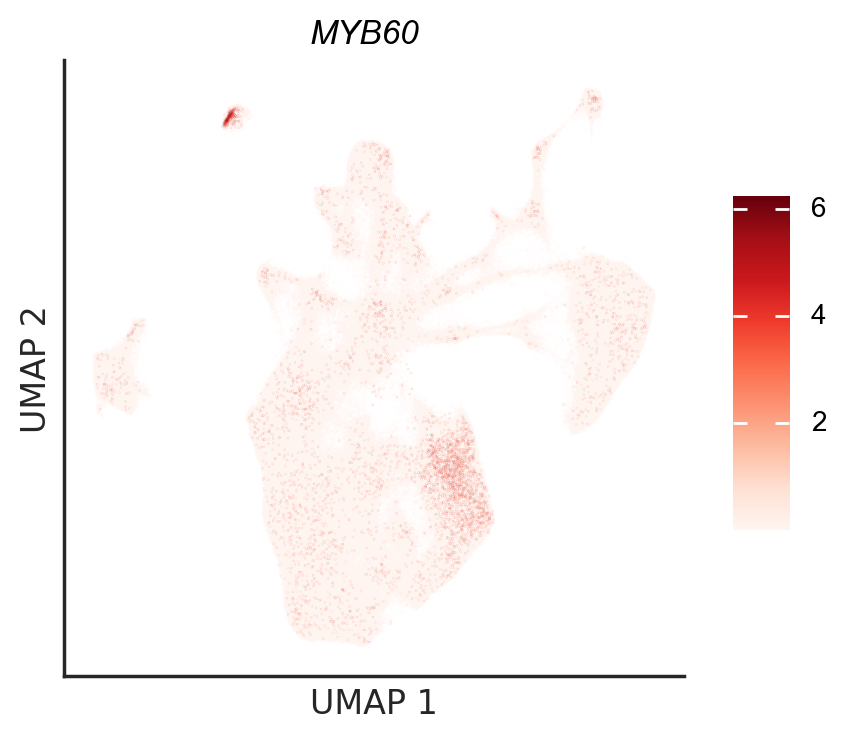

In [ ]:
ead.pl.embedding(color='AT1G08810', size=0.03, title='MYB60', figsize=(4,4))

In [ ]:
import matplotlib.ticker as ticker

In [ ]:
a = ticker.FixedLocator([-np.log10(0.05), 2, 4, 6, 8])

In [ ]:
import legendkit

In [ ]:
lambda _, a: -np.log10(10**_)(0)

<function __main__.<lambda>(_, a)>

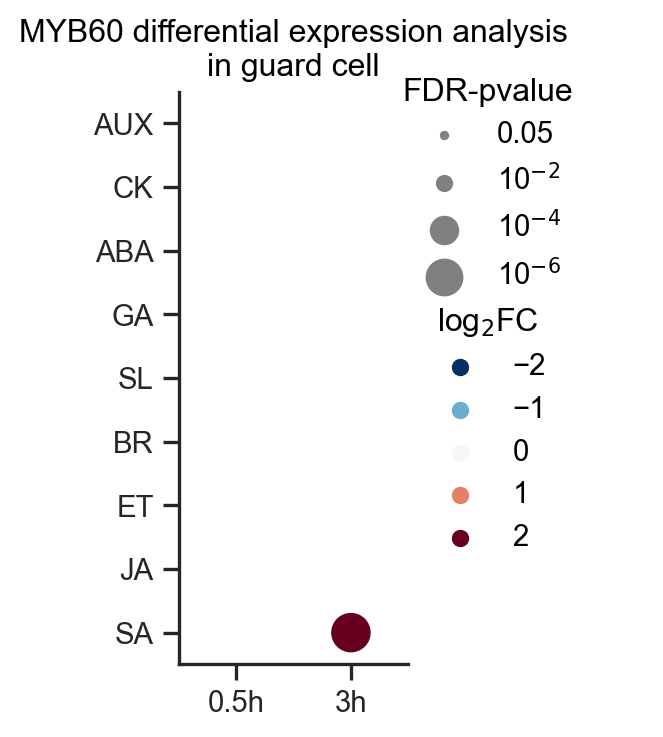

In [ ]:
def _fc(x, y):
    if np.abs(-np.log10(0.05) - x) < 0.001:
        return 0.05
    else:
        return f"10$^{{{int(-x)}}}$"

df_tempPlot = (
    ead.uns["de_Sample_deg"]
    .query("gene == 'AT1G08810' & cluster == '24'")
    .assign(**{"-log10(fdr)": lambda _: -np.log10(_["fdr"])})
)
(
    so.Plot(
        data=df_tempPlot,
        y="Hormone",
        x="Time",
        pointsize="-log10(fdr)",
        color="logFC",
    )
    .add(so.Dot())
    .label(
        x="",
        y="",
        pointsize="FDR-pvalue",
        color="log$_2$FC",
        title="MYB60 differential expression analysis\nin guard cell",
    )
    .scale(
        pointsize=so.Continuous(
            values=(3, 15), norm=(-np.log10(0.05), -np.log10(10**-7))
        ).tick(at=[-np.log10(0.05), 2, 4, 6]).label(like=_fc),
        color=so.Continuous(values="RdBu_r", norm=(-2, 2)),
    )
    .layout(size=(2, 4))
)

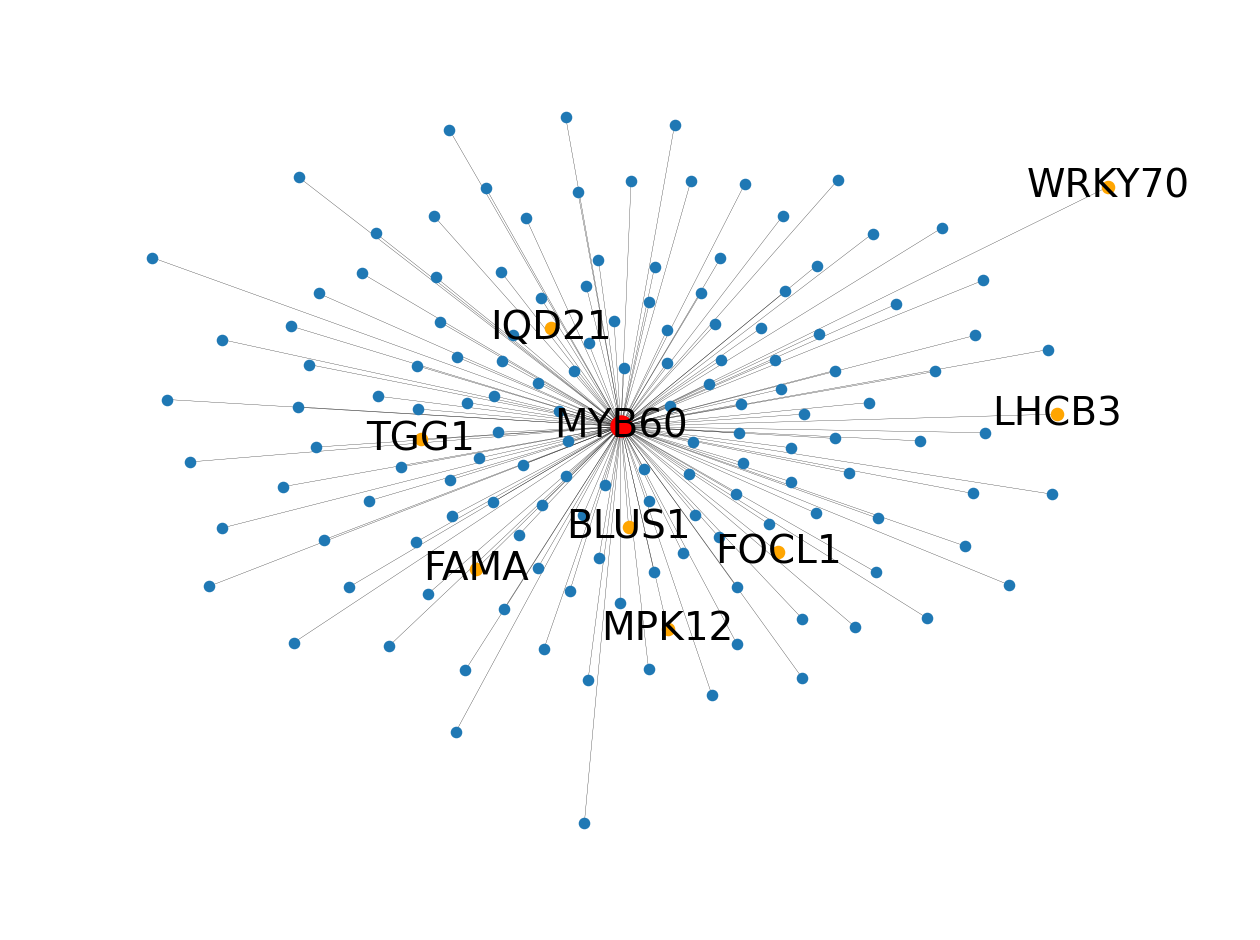

In [ ]:
G = nx.Graph()
for _, row in df_edge.iterrows():
    G.add_edge(row["TF"], row["TG"], weight=np.cbrt(row["weight"]))
pos = nx.spring_layout(G)  # positions for all nodes - seed for reproducibility
nx.draw_networkx_nodes(G, pos, node_size=10)
nx.draw_networkx_nodes(
    G, pos, nodelist=["AT1G08810"], **{"node_size": 50, "node_color": "r"}
)
nx.draw_networkx_edges(G, pos, width=0.1)

ls_stomatalRelatedTf = []
for gene in ls_myb60TgStoRelated:
    ls_stomatalRelatedTf.append(gene)
nx.draw_networkx_nodes(
    G, pos, nodelist=ls_stomatalRelatedTf, **{"node_size": 15, "node_color": "orange"}
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=dt_myb50TgStoRelated,
    font_size=14,
    font_family="sans-serif",
    verticalalignment="center",
    horizontalalignment="center",
)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()